# Учебная задача «Анализ сайта»

**Цель и ожидаемый результат**

Компания «СберАвтоподписка» хочет увеличить эффективность сайта: улучшить пользовательский опыт, повысить конверсию, сделать рекламные кампании более результативными. Для этого вам предстоит создать модель, которая предсказывает вероятность того, что пользователь совершит целевое действие (оставит заявку, закажет звонок и пр.) на сайте.

**О компании «СберАвтоподписка»**
СберАвтоподписка — это сервис долгосрочной аренды автомобилей для физических лиц. Клиент платит фиксированную сумму в месяц и получает авто в пользование сроком от 6 месяцев до 3 лет.

В стоимость включены:
- Страхование (КАСКО, ОСАГО, ДСАГО);
- ТО и ремонт;
- Сезонная смена и хранение шин;
- Круглосуточная поддержка.

Дополнительно можно заказать консьерж-сервис — доставка автомобиля в сервис и обратно.

Сервис выступает альтернативой покупке авто или автокредиту — машину выгоднее арендовать, а средства инвестировать.


Решение представленное в данной работе поможет:

- Оценивать эффективность каналов привлечения трафика;
- Адаптировать рекламные кампании;
- Улучшать UX сайта за счет анализа поведения пользователей.

Выполнил студент М2551187

Импортируем библиотеки, необходимые для данной задачи

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Подготовка и очистка данных

Нам предоставлен лог пользовательских действий на сайте и дополнительные данные по сессиям.

Некоторые атрибуты:
-	utm_, geo_, device_ — характеристики визитов;
-	ga_hits.hit_page_path — страницы сайта;
-	ga_sessions.utm_medium/source — источники трафика.

Считывание данных

In [2]:
sessions = pd.read_pickle('C:\\Users\\agavr\\Downloads\\mf_data\\ga_sessions.pkl')
hits = pd.read_pickle('C:\\Users\\agavr\\Downloads\\mf_data\\ga_hits.pkl')

print(f"Размер сессий: {sessions.shape}")
print(f"Размер событий: {hits.shape}")

Размер сессий: (1860042, 18)
Размер событий: (15726470, 11)


Получим информацию о данных и примеры записей из таблицы сессий

In [3]:
sessions.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Non-Null Count    Dtype 
---  ------                    --------------    ----- 
 0   session_id                1860042 non-null  object
 1   client_id                 1860042 non-null  object
 2   visit_date                1860042 non-null  object
 3   visit_time                1860042 non-null  object
 4   visit_number              1860042 non-null  int64 
 5   utm_source                1859945 non-null  object
 6   utm_medium                1860042 non-null  object
 7   utm_campaign              1640439 non-null  object
 8   utm_adcontent             1524427 non-null  object
 9   utm_keyword               777981 non-null   object
 10  device_category           1860042 non-null  object
 11  device_os                 789904 non-null   object
 12  device_brand              1741364 non-null  object
 13  device_model              16338 non-null  

In [4]:
sessions.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


Получим информацию о данных и примеры записей из таблицы событий

In [5]:
hits.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Non-Null Count     Dtype  
---  ------          --------------     -----  
 0   session_id      15726470 non-null  object 
 1   hit_date        15726470 non-null  object 
 2   hit_time        6566148 non-null   float64
 3   hit_number      15726470 non-null  int64  
 4   hit_type        15726470 non-null  object 
 5   hit_referer     9451666 non-null   object 
 6   hit_page_path   15726470 non-null  object 
 7   event_category  15726470 non-null  object 
 8   event_action    15726470 non-null  object 
 9   event_label     11966286 non-null  object 
 10  event_value     0 non-null         object 
dtypes: float64(1), int64(1), object(9)
memory usage: 1.3+ GB


In [6]:
hits.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,None
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,None
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,None
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,None
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,None


In [7]:
# Проверка пропусков
print("Пропуски в сессиях:")
sessions.isnull().sum()

Пропуски в сессиях:


session_id                        0
client_id                         0
visit_date                        0
visit_time                        0
visit_number                      0
utm_source                       97
utm_medium                        0
utm_campaign                 219603
utm_adcontent                335615
utm_keyword                 1082061
device_category                   0
device_os                   1070138
device_brand                 118678
device_model                1843704
device_screen_resolution          0
device_browser                    0
geo_country                       0
geo_city                          0
dtype: int64

In [8]:
print("Пропуски в событиях:")
hits.isnull().sum()

Пропуски в событиях:


session_id               0
hit_date                 0
hit_time           9160322
hit_number               0
hit_type                 0
hit_referer        6274804
hit_page_path            0
event_category           0
event_action             0
event_label        3760184
event_value       15726470
dtype: int64

Из проверок выше можно сделать вывод о том, что в таблице сессий довольно вного пропусков в 6 атрибутах, в то время как в таблице событий в 3 столбцах большая доля пропусков, а в одном столбце нет ни одного зхначения. Обработем эти признаки в дальнейшем.

Получим перечень топ-20 типов целевых действий

In [9]:
all_actions = hits['event_action'].value_counts().reset_index()
all_actions.columns = ['event_action', 'frequency']

print(f"Уникальных типов целевых событий (event_action): {len(all_actions)}")
all_actions.head(20)


Уникальных типов целевых событий (event_action): 230


,event_action,frequency
0,view_card,3558985
1,view_new_card,3551009
2,sub_landing,1798117
3,go_to_car_card,973666
4,sub_view_cars_click,791515
5,search_form_region,512069
6,search_form_search_btn,433748
7,sap_search_form_cost_to,356596
8,showed_number_ads,326274
9,pagination_click,248944


In [10]:
# Фиксируем целевые действия  
target_actions = [
    'sub_car_claim_click', 'sub_car_claim_submit_click',
    'sub_call_number_click', 'sub_callback_submit_click',
    'sub_submit_success', 'sub_car_request_submit_click',
    'sub_open_dialog_click', 'sub_custom_question_submit_click',
    'greenday_sub_submit_success', 'greenday_sub_callback_submit_click',
    'greenday_sub_open_dialog_click', 'greenday_sub_call_number_click'
]

Осуществим поиск utm-меток, которые относятся к социальным сетям

In [11]:
social_mask = sessions['utm_medium'].str.contains('SMM|social|network|sm', case=False, na=False)
social_ids = sessions[social_mask]['utm_source'].unique()

print("Идентификаторы источников трафика (utm_source), отнесенные к категории Social:")
social_ids

Идентификаторы источников трафика (utm_source), отнесенные к категории Social:


array(['ISrKoXQCxqqYvAZICvjs', 'nSReTmyFtbSjlPrTKoaX',
       'ZpYIoDJMcFzVoPFsHGJL', 'iNFgfQPqHPBuvGCYtrQE',
       'QxAxdyPLuQMEcrdZWdWb', 'bByPQxmDaMXgpHeypKSM',
       'eimRuUrNhZLAYcwRrNXu'], dtype=object)

In [12]:
# Рассмотрим топ источников 
print("Распределение визитов по Топ-10 источникам:")
sessions['utm_source'].value_counts().head(10)

Распределение визитов по Топ-10 источникам:


utm_source
ZpYIoDJMcFzVoPFsHGJL    578290
fDLlAcSmythWSCVMvqvL    300575
kjsLglQLzykiRbcDiGcD    266354
MvfHsxITijuriZxsqZqt    186199
BHcvLfOaCWvWTykYqHVe    116320
bByPQxmDaMXgpHeypKSM    102287
QxAxdyPLuQMEcrdZWdWb     51415
aXQzDWsJuGXeBXexNHjc     31152
jaSOmLICuBzCFqHfBdRg     29241
RmEBuqrriAfAVsLQQmhk     28055
Name: count, dtype: int64

Перейдем к формированию объединенного датасета

In [13]:
organic_mediums = ['organic', 'referral', '(none)']
social_sources = list(social_ids)

# Осуществляем разметку целевых действий в таблице событий
hits['is_target'] = hits['event_action'].isin(target_actions).astype(int)
target_sessions = hits.groupby('session_id')['is_target'].max().reset_index()

df = pd.merge(sessions, target_sessions, on='session_id', how='left')
df['is_target'] = df['is_target'].fillna(0).astype(int)

df['is_organic'] = df['utm_medium'].isin(organic_mediums).astype(int)
df['is_social'] = df['utm_source'].isin(social_sources).astype(int)
df['is_paid'] = 1 - df['is_organic']
print(f"Размерность датасета: {df.shape}")
print(f"Базовая конверсия (доля целевого класса): {df['is_target'].mean()*100:.2f}%")

Размерность датасета: (1860042, 22)
Базовая конверсия (доля целевого класса): 2.74%


В рамках подготовитьельного этапа выделено 12 целевых действий, что позволило бинаризовать целевой признак - базовая конверсия сессий в целевое действие составила 2.74%. Сформирован объединенный датасет с дополнительными признаками: is_target, is_organic (organic, referral, (none)), is_social (выделено через utm_medium с SMM/social/network/sm), is_paid. Это позволяет переходить к анализу влияния каналов трафика на конверсию и построению прогнозных моделей бинарной классификации.

## 2. Разведочный анализ данных (EDA)

Перейдем к разведочному анализ данных (EDA), который позволит обоснованно выбрать методы предобработки и моделирования, сформировать новые признаки, а также сформулировать гипотезы о факторах, влияющих на целевую переменную.

Создание временных признаков 

In [14]:
# Конвертируем visit_date в datetime 
df['visit_date'] = pd.to_datetime(df['visit_date'])

# Конвертируем visit_time в строку (если это time object)
if df['visit_time'].dtype == 'object' or 'time' in str(df['visit_time'].dtype):
    df['visit_time_str'] = df['visit_time'].astype(str)
else:
    df['visit_time_str'] = df['visit_time']

# Создаем datetime объект, объединяя дату и время
df['visit_datetime'] = pd.to_datetime(
    df['visit_date'].dt.strftime('%Y-%m-%d') + ' ' + df['visit_time_str']
)

# Извлекаем временные признаки
df['visit_hour'] = df['visit_datetime'].dt.hour
df['visit_dayofweek'] = df['visit_datetime'].dt.dayofweek
df['visit_month'] = df['visit_datetime'].dt.month
df['is_weekend'] = (df['visit_dayofweek'] >= 5).astype(int)

# Удаляем временный столбец
df.drop('visit_time_str', axis=1, inplace=True)

# Время суток
def get_time_period(hour):
    if 5 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 22:
        return 'evening'
    else:
        return 'night'

df['time_period'] = df['visit_hour'].apply(get_time_period)

print("Временные признаки успешно созданы!")
print(df[['visit_datetime', 'visit_hour', 'visit_dayofweek', 'time_period']].head())

Временные признаки успешно созданы!
       visit_datetime  visit_hour  visit_dayofweek time_period
0 2021-11-24 14:36:32          14                2   afternoon
1 2021-11-14 08:21:30           8                6     morning
2 2021-12-28 02:42:06           2                1       night
3 2021-05-29 05:00:00           5                5     morning
4 2021-05-29 05:00:00           5                5     morning


Перейдем к созданию поведенческих признаков из таблицы событий.

В начале необходимо проверить наличие действий у клиента после совершения целевого действий.  Так как при построении модели прогнозирования конверсии мы создаем поведенческие признаки, такие как total_hits (общее количество событий), car_page_views (просмотры автомобилей), form_interactions (взаимодействие с формами) и session_duration_sec (длительность сессии). Если в данных присутствуют события, произошедшие после того, как пользователь уже совершил целевое действие (отправил заявку, заказал звонок), то эти признаки будут содержать информацию из будущего относительно момента конверсии. Другими словами, модель будет "видеть" то, что произошло после целевого действия, и использовать эти данные для предсказания самого целевого действия.

In [15]:
# Функция для конвертации времени в секунды
def time_to_seconds(time_str):
    try:
        if pd.isna(time_str):
            return 0
        parts = str(time_str).split(':')
        if len(parts) == 3:
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        return 0
    except:
        return 0

# Добавляем временные метки в секундах
hits['hit_time_seconds'] = hits['hit_time'].apply(time_to_seconds)

# Находим время конверсии для каждой сессии
first_conversion_time = hits[hits['is_target'] == 1].groupby('session_id')['hit_time_seconds'].min().reset_index()
first_conversion_time.columns = ['session_id', 'first_conversion_time']

# Объединяем с hits
hits_with_conversion = hits.merge(first_conversion_time, on='session_id', how='left')

# Создаем флаг: событие до конверсии (или все события, если конверсии нет)
hits_with_conversion['is_before_conversion'] = (
    (hits_with_conversion['first_conversion_time'].isna()) |  # нет конверсии - берем все события
    (hits_with_conversion['hit_time_seconds'] <= hits_with_conversion['first_conversion_time'])  # до конверсии
)

# Фильтруем только события до конверсии
hits_before = hits_with_conversion[hits_with_conversion['is_before_conversion']].copy()

print(f"Событий до фильтрации: {len(hits)}")
print(f"Событий после фильтрации (только до конверсии): {len(hits_before)}")
print(f"Исключено событий после конверсии: {len(hits) - len(hits_before)}")

Событий до фильтрации: 15726470
Событий после фильтрации (только до конверсии): 15726470
Исключено событий после конверсии: 0


In [16]:
# Аггрегируем поведенческие метрики на основе событий до конверсии
behavioral_features = hits_before.groupby('session_id').agg(
    total_hits=('hit_number', 'count'),
    unique_pages=('hit_page_path', 'nunique'),
    total_events=('event_action', 'count')
).reset_index()

# Просмотры карточек автомобилей (только до конверсии)
hits_before['is_car_page'] = hits_before['hit_page_path'].str.contains('car|auto|model', case=False, na=False)
car_views = hits_before.groupby('session_id')['is_car_page'].sum().reset_index(name='car_page_views')

# Взаимодействие с формами (только до конверсии)
hits_before['is_form_interaction'] = hits_before['event_action'].str.contains('form|input|submit|callback', case=False, na=False)
form_interactions = hits_before.groupby('session_id')['is_form_interaction'].sum().reset_index(name='form_interactions')

# Длительность сессии ДО конверсии
session_times_before = hits_before.groupby('session_id').agg(
    first_time=('hit_time_seconds', 'first'),
    last_time=('hit_time_seconds', 'last')
).reset_index()
session_times_before['session_duration_sec'] = session_times_before['last_time'] - session_times_before['first_time']
session_times_before['session_duration_sec'] = session_times_before['session_duration_sec'].fillna(0).clip(lower=0)

# Объединяем все поведенческие признаки с df
df = df.merge(behavioral_features, on='session_id', how='left')
df = df.merge(car_views, on='session_id', how='left')
df = df.merge(form_interactions, on='session_id', how='left')
df = df.merge(session_times_before[['session_id', 'session_duration_sec']], on='session_id', how='left')

# Заполняем пропуски в поведенческих признаках
behavioral_cols = ['total_hits', 'unique_pages', 'total_events', 'car_page_views', 
                   'form_interactions', 'session_duration_sec']
for col in behavioral_cols:
    df[col] = df[col].fillna(0)

print(f"Среднее total_hits: {df['total_hits'].mean():.2f}")
print(f"Среднее car_page_views: {df['car_page_views'].mean():.2f}")

Среднее total_hits: 8.43
Среднее car_page_views: 8.42


Создадим признаки разрешения экрана, для определения того, с каких устройств мы получаем больше всего взаимодействия 

In [17]:
# Функция парсит разрешение экрана и возвращает ширину и высоту
def parse_screen_resolution(resolution):
    if pd.isna(resolution) or resolution == '(not set)' or resolution == '':
        return 0, 0
    try:
        parts = str(resolution).split('x')
        if len(parts) == 2:
            width = float(parts[0]) if parts[0].replace('.', '').isdigit() else 0
            height = float(parts[1]) if parts[1].replace('.', '').isdigit() else 0
            return width, height
        else:
            return 0, 0
    except:
        return 0, 0

# Применяем функцию
df[['screen_width', 'screen_height']] = df['device_screen_resolution'].apply(
    lambda x: pd.Series(parse_screen_resolution(x))
)

# Признак мобильного устройства (более детальный)
df['is_mobile'] = (df['device_category'] == 'mobile').astype(int)
df['is_tablet'] = (df['device_category'] == 'tablet').astype(int)
df['is_desktop'] = (df['device_category'] == 'desktop').astype(int)

print(f"Уникальные разрешения: {df['device_screen_resolution'].nunique()}")
print(f"Средняя ширина: {df['screen_width'].mean():.0f}")
print(f"Средняя высота: {df['screen_height'].mean():.0f}")
print(f"Доля мобильных: {df['is_mobile'].mean():.2%}")
print(f"Доля десктоп: {df['is_desktop'].mean():.2%}")

Уникальные разрешения: 5039
Средняя ширина: 657
Средняя высота: 841
Доля мобильных: 79.29%
Доля десктоп: 19.72%


Перейдем к визуализации

Для начала посмотрим на расмпределение целевой переменной - конверсии

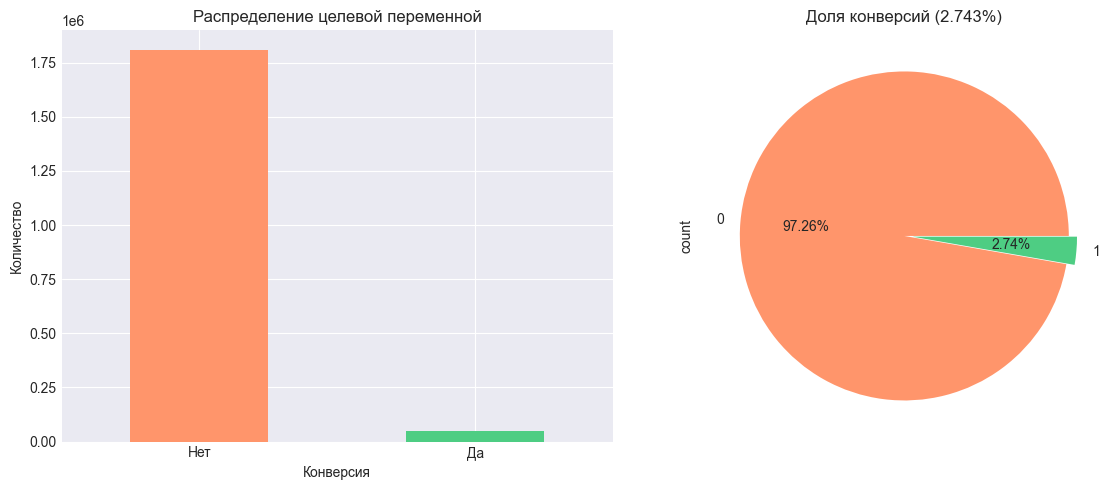

In [18]:
# Визуализация дисбаланса
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df['is_target'].value_counts().plot(kind='bar', ax=ax[0], color=["#ff956b", "#4ecd83"])
ax[0].set_title('Распределение целевой переменной')
ax[0].set_xlabel('Конверсия')
ax[0].set_ylabel('Количество')
ax[0].set_xticklabels(['Нет', 'Да'], rotation=0)

# Pie chart
df['is_target'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.2f%%', 
                                    colors=["#ff956b", "#4ecd83"], explode=[0, 0.05])
ax[1].set_title(f'Доля конверсий ({df["is_target"].mean()*100:.3f}%)')

plt.tight_layout()
plt.show()


Из визуализации выше можно сделать вывод о наличии дисбаланса классов, что логично, так как количество сессий без целевого действия значительно превышает количество сессий с целевым действием. Это характерно для задач анализа конверсии, где большинство пользователей не доходят до целевого события. Такой дисбаланс необходимо учитывать при обучении модели, например, с помощью использования метрик вроде precision, recall.

Изучим клиентов более подробно с помощью различных группировок ниже.

Посмотрим какой тип устройств пнаиболе эффективен, откуда приходит больше всего трафика - из соцсетей или иных источников, в какие часы дня и в какие дни показатели конверсии наибольшие и поведенчие метрики.

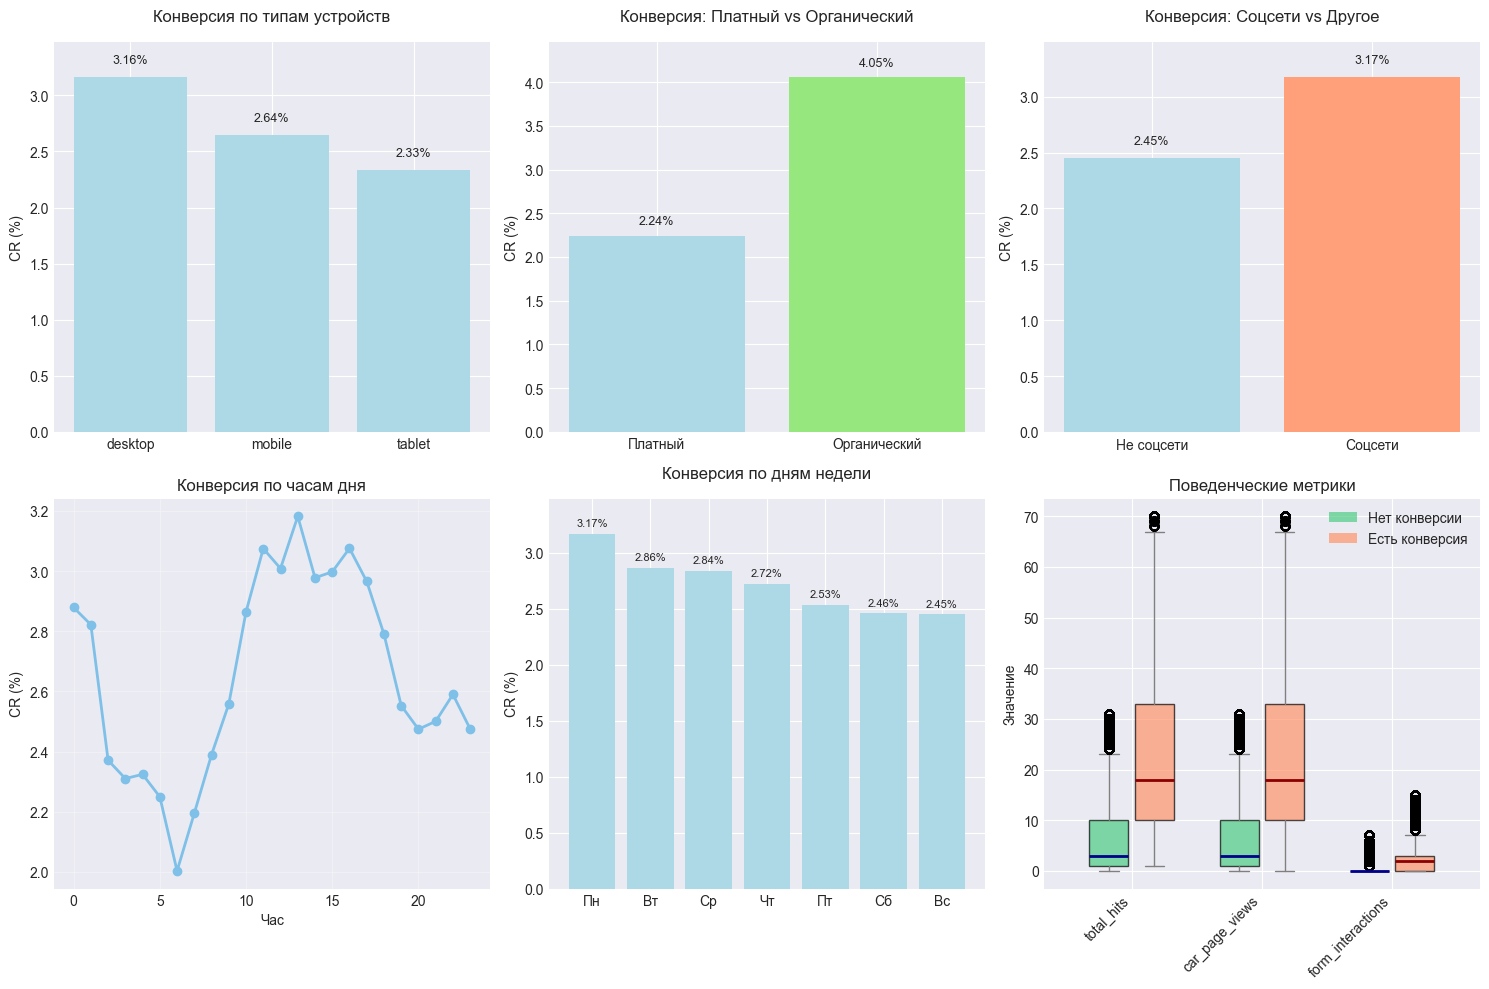

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# По типам устройств
device_cr = df.groupby('device_category')['is_target'].agg(['mean', 'count']).sort_values('mean', ascending=False)
bars = axes[0, 0].bar(device_cr.index, device_cr['mean']*100, color='lightblue')
axes[0, 0].set_title('Конверсия по типам устройств', pad=15)
axes[0, 0].set_ylabel('CR (%)')
axes[0, 0].set_ylim(0, device_cr['mean'].max() * 100 * 1.1)
for bar, v in zip(bars, device_cr['mean']*100):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

# По типу трафика
traffic_cr = df.groupby('is_organic')['is_target'].mean()
bars = axes[0, 1].bar(['Платный', 'Органический'], traffic_cr*100, color=['lightblue', '#95e77e'])
axes[0, 1].set_title('Конверсия: Платный vs Органический', pad=15)
axes[0, 1].set_ylabel('CR (%)')
axes[0, 1].set_ylim(0, traffic_cr.max() * 100 * 1.1)
for bar, v in zip(bars, traffic_cr*100):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

# По соцсетям
social_cr = df.groupby('is_social')['is_target'].mean()
bars = axes[0, 2].bar(['Не соцсети', 'Соцсети'], social_cr*100, color=['lightblue', '#ffa07a'])
axes[0, 2].set_title('Конверсия: Соцсети vs Другое', pad=15)
axes[0, 2].set_ylabel('CR (%)')
axes[0, 2].set_ylim(0, social_cr.max() * 100 * 1.1)
for bar, v in zip(bars, social_cr*100):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

# По часам дня
hourly_cr = df.groupby('visit_hour')['is_target'].mean()
axes[1, 0].plot(hourly_cr.index, hourly_cr*100, marker='o', color="#7ec0e7", linewidth=2)
axes[1, 0].set_title('Конверсия по часам дня')
axes[1, 0].set_xlabel('Час')
axes[1, 0].set_ylabel('CR (%)')
axes[1, 0].grid(True, alpha=0.3)

# По дням недели
weekday_cr = df.groupby('visit_dayofweek')['is_target'].mean()
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
bars = axes[1, 1].bar(weekday_names, weekday_cr*100, color='lightblue')
axes[1, 1].set_title('Конверсия по дням недели', pad=15)
axes[1, 1].set_ylabel('CR (%)')
axes[1, 1].set_ylim(0, weekday_cr.max() * 100 * 1.1)
for bar, v in zip(bars, weekday_cr*100):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                    f'{v:.2f}%', ha='center', va='bottom', fontsize=8)

# Поведенческие метрики (boxplot с цветами)
behavioral_for_box = ['total_hits', 'car_page_views', 'form_interactions']

# Подготавливаем данные
data_no_conv = []
data_conv = []
for metric in behavioral_for_box:
    # Группа без конверсии (is_target = 0)
    values_no_conv = df[df['is_target'] == 0][metric].clip(
        upper=df[df['is_target'] == 0][metric].quantile(0.95)
    )
    # Группа с конверсией (is_target = 1)
    values_conv = df[df['is_target'] == 1][metric].clip(
        upper=df[df['is_target'] == 1][metric].quantile(0.95)
    )
    data_no_conv.append(values_no_conv)
    data_conv.append(values_conv)

# Создаем позиции для boxplot'ов
positions_no_conv = np.arange(len(behavioral_for_box))  # [0, 1, 2]
positions_conv = [x + 0.35 for x in range(len(behavioral_for_box))]  # [0.35, 1.35, 2.35]

# Рисуем boxplot'ы с разными цветами
bp1 = axes[1, 2].boxplot(data_no_conv, positions=positions_no_conv, widths=0.3,
                         patch_artist=True,  # чтобы можно было залить цветом
                         boxprops=dict(facecolor='#4ecd83', alpha=0.7, label='Нет конверсии'),
                         medianprops=dict(color='darkblue', linewidth=2),
                         whiskerprops=dict(color='gray'),
                         capprops=dict(color='gray'))

bp2 = axes[1, 2].boxplot(data_conv, positions=positions_conv, widths=0.3,
                         patch_artist=True,
                         boxprops=dict(facecolor='#ff956b', alpha=0.7, label='Есть конверсия'),
                         medianprops=dict(color='darkred', linewidth=2),
                         whiskerprops=dict(color='gray'),
                         capprops=dict(color='gray'))

# Настройка осей
axes[1, 2].set_xticks([x + 0.175 for x in range(len(behavioral_for_box))])
axes[1, 2].set_xticklabels(behavioral_for_box, rotation=45, ha='right')
axes[1, 2].set_title('Поведенческие метрики')
axes[1, 2].set_ylabel('Значение')

# Добавляем легенду
legend_elements = [Patch(facecolor='#4ecd83', alpha=0.7, label='Нет конверсии'),
                   Patch(facecolor='#ff956b', alpha=0.7, label='Есть конверсия')]
axes[1, 2].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

Из графиков выше можно увидеть, что наибольшая конверсия по типам устройств - у desktop: клиенты чаще совершают целевое действие за компьютером, нежели при использовании планшета или телефона. Конверсия органического трафика в два раза выше, чем у платного. С точки зрения источника наибольшая конверсия совершения действия наблюдается в социальных сетях, однако иные источники не сильно им уступают.

Наиболее высокий шанс совершения целевого действия клиентом - в период с 10:00 до 17:00 (достигается уровень конверсии 3.17%). Если анализировать конверсию по дням недели, то наибольшая доля конверсий приходится на понедельник (3.17%) и плавно снижается к воскресенью, достигая значения 2.45%. На последней диаграмме видно, что клиенты, совершившие целевое действие, производят наибольшее количество взаимодействий с продуктом: в среднем у них 18 просмотров страниц, тогда как у пользователей, не совершивших целевое действие - 4-5.

Корреляционный анализ 

Найдено признаков для корреляции: 19
Отсутствуют: []


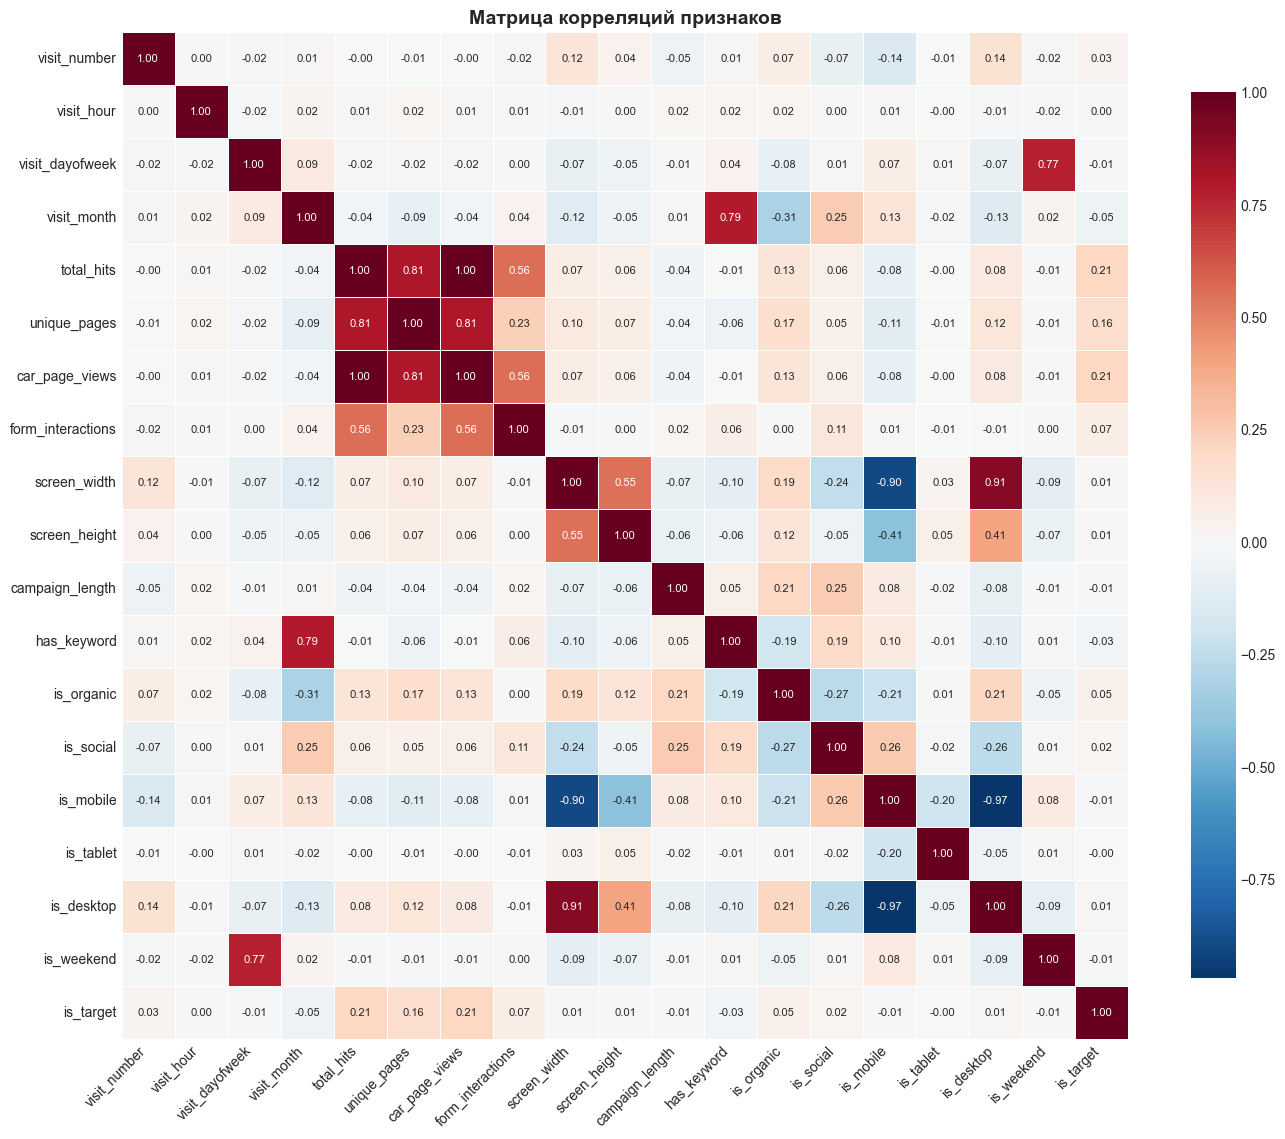

In [20]:
# Сначала создадим признаки длина названия кампании и наличие ключевого слова
if 'campaign_length' not in df.columns:
    df['campaign_length'] = df['utm_campaign'].fillna('').str.len()

if 'has_keyword' not in df.columns:
    df['has_keyword'] = (df['utm_keyword'].fillna('') != '').astype(int)

numeric_features = ['visit_number', 'visit_hour', 'visit_dayofweek', 'visit_month', 
                   'total_hits', 'unique_pages', 'car_page_views', 'form_interactions', 
                   'screen_width', 'screen_height', 'campaign_length', 'has_keyword', 'is_organic', 'is_social', 
                   'is_mobile', 'is_tablet', 'is_desktop', 'is_weekend', 'is_target']

existing_features = [col for col in numeric_features if col in df.columns]
print(f"Найдено признаков для корреляции: {len(existing_features)}")
print("Отсутствуют:", [col for col in numeric_features if col not in df.columns])

# Выбираем только существующие столбцы
numeric_df = df[existing_features].copy()

# Корреляционная матрица
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, 
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
plt.title('Матрица корреляций признаков', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# Корреляции с целевой переменной
print("Корреляции с целевой переменной:")
if 'is_target' in corr_matrix.columns:
    corr_with_target = corr_matrix['is_target'].sort_values(ascending=False)
    for feature, corr in corr_with_target.items():
        if feature != 'is_target' and abs(corr) > 0.01:
            print(f"{feature:25s}: {corr:.4f}")

Корреляции с целевой переменной:
car_page_views           : 0.2061
total_hits               : 0.2058
unique_pages             : 0.1638
form_interactions        : 0.0705
is_organic               : 0.0498
visit_number             : 0.0256
is_social                : 0.0218
is_desktop               : 0.0127
is_mobile                : -0.0119
campaign_length          : -0.0140
visit_dayofweek          : -0.0143
has_keyword              : -0.0328
visit_month              : -0.0511


Наибольшее положительное влияние на совершение целевого действия оказывают поведенческие признаки: количество просмотров страниц с автомобилями (car_page_views, 0.206), общее число событий (total_hits, 0.206) и количество уникальных страниц (unique_pages, 0.164). Признаки канала трафика (is_organic, is_social, is_desktop) имеют слабую положительную корреляцию, тогда как временные признаки (visit_month, visit_dayofweek) и наличие ключевого слова (has_keyword) показывают очень слабую отрицательную связь. Это говорит о том, что для прогнозирования конверсии ключевое значение имеет активность пользователя на сайте, а не столько источник визита или временные характеристики.

Проведем анализ топ-источников трафика

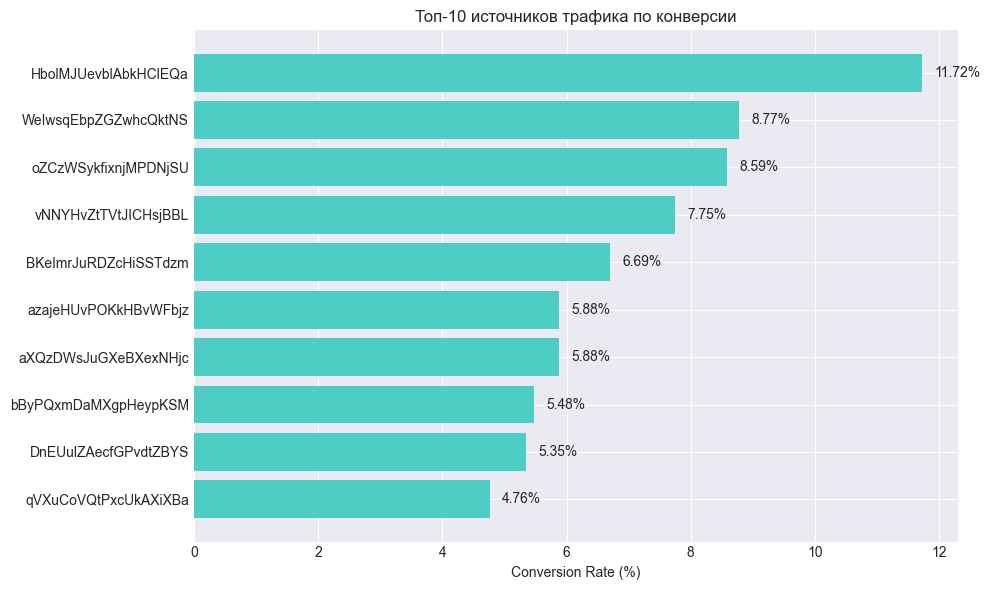

In [22]:
# Топ-10 источников по конверсии
source_cr = df.groupby('utm_source').agg(
    conversions=('is_target', 'sum'),
    total=('session_id', 'count'),
    cr=('is_target', 'mean')
).reset_index()
source_cr = source_cr[source_cr['total'] > 100].sort_values('cr', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(source_cr)), source_cr['cr']*100, color='#4ecdc4')
ax.set_yticks(range(len(source_cr)))
ax.set_yticklabels(source_cr['utm_source'])
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Топ-10 источников трафика по конверсии')
ax.invert_yaxis()

for i, v in enumerate(source_cr['cr']*100):
    ax.text(v + 0.2, i, f'{v:.2f}%', va='center')

plt.tight_layout()
plt.show()

In [23]:
print("Топ-10 источников по объему трафика:")
source_cr[['utm_source', 'total', 'conversions', 'cr']].head(10)

Топ-10 источников по объему трафика:


,utm_source,total,conversions,cr
45,HbolMJUevblAbkHClEQa,128,15,0.117188
131,WeIwsqEbpZGZwhcQktNS,114,10,0.087719
241,oZCzWSykfixnjMPDNjSU,3143,270,0.085905
270,vNNYHvZtTVtJICHsjBBL,129,10,0.077519
6,BKeImrJuRDZcHiSSTdzm,1464,98,0.066940
160,azajeHUvPOKkHBvWFbjz,204,12,0.058824
158,aXQzDWsJuGXeBXexNHjc,31152,1831,0.058776
161,bByPQxmDaMXgpHeypKSM,102287,5607,0.054816
23,DnEUulZAecfGPvdtZBYS,1420,76,0.053521
248,qVXuCoVQtPxcUkAXiXBa,798,38,0.047619


Проведенный EDA позволил не только формально описать данные, но и содержательно интерпретировать поведение пользователей. Ключевая интерпретация: тот факт, что поведенческие признаки имеют наибольшую корреляцию с конверсией (около 0.2) означает, что пользователи принимают решение о целевом действии не мгновенно, а в процессе активного изучения сайта. Чем больше страниц с автомобилями он просмотрел и чем больше взаимодействий совершил, тем выше вероятность конверсии. При этом слабая корреляция каналов трафика говорит о том, что источник визита важен, но не является определяющим - качество вовлечения пользователя на сайте перевешивает канал прихода.

Наиболее высокая конверсия в понедельник и в рабочие часы (10:00–17:00) может указывать на то, что целевая аудитория — работающие люди, которые принимают решения в офисное время, вероятно, в рамках профессиональной деятельности или в обеденные перерывы. Преимущество десктопов перед мобильными устройствами объясняется сложностью форм и объемом информации: заполнение заявок или просмотр характеристик автомобилей удобнее с полноразмерного экрана. А тот факт, что органический трафик конвертируется в два раза лучше платного, интерпретируется как более высокая лояльность и целенаправленность пользователей, которые нашли сайт самостоятельно (через поиск или прямой переход), в отличие от тех, кто пришел по рекламе.

## 3. Обучение моделей 

Перейдем к обучению моделей.

В данной задаче рассматриваются 3 наиболее популярные и практичные модели:
- Логистическая регрессия 
- Случайный лес
- Градиентный бустинг

In [ ]:
# Определяем все потенциально полезные признаки
all_potential_features = [
    # Числовые признаки
    'visit_number', 'visit_hour', 'visit_dayofweek', 'visit_month',
    'total_hits', 'unique_pages', 'car_page_views', 'form_interactions',
    'session_duration_sec', 'screen_width', 'screen_height',
    'campaign_length', 'has_keyword',
    
    # Бинарные признаки
    'is_organic', 'is_social', 'is_paid', 'is_mobile', 'is_tablet', 
    'is_desktop', 'is_weekend',
    
    # Категориальные (закодируем через LabelEncoder)
    'utm_source', 'utm_medium', 'utm_campaign',
    'device_category', 'device_os', 'device_brand', 'device_browser',
    'geo_country', 'geo_city', 'time_period'
]

existing_features = [col for col in all_potential_features if col in df.columns]

# Создаем X и y
X = df[existing_features].copy()
y = df['is_target'].copy()

# Кодируем категориальные признаки
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"\nКатегориальные признаки: {list(categorical_cols)}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f" - {col}: {len(le.classes_)} значений")
    
# Проверяем
print(f"\nТипы данных после кодирования:")
print(X.dtypes.value_counts())
print(f"Пропуски: {X.isnull().sum().sum()}")


Категориальные признаки: ['utm_source', 'utm_medium', 'utm_campaign', 'device_category', 'device_os', 'device_brand', 'device_browser', 'geo_country', 'geo_city', 'time_period']
 - utm_source: 294 значений
 - utm_medium: 56 значений
 - utm_campaign: 413 значений
 - device_category: 3 значений
 - device_os: 14 значений
 - device_brand: 207 значений
 - device_browser: 57 значений
 - geo_country: 166 значений
 - geo_city: 2548 значений
 - time_period: 4 значений

Типы данных после кодирования:
int32      21
float64     7
int64       2
Name: count, dtype: int64
Пропуски: 0


In [25]:
# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8. Масштабируем
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f" Размерность X_train = {X_train.shape}")
print(f" Размерность X_test = {X_test.shape}")

 Размерность X_train = (1488033, 30)
 Размерность X_test = (372009, 30)


In [26]:
print("Логистическая регрессия")
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, C=0.1)
lr_model.fit(X_train, y_train)

lr_train_pred = lr_model.predict_proba(X_train)[:, 1]
lr_test_pred = lr_model.predict_proba(X_test)[:, 1]

print(f"Train ROC-AUC: {roc_auc_score(y_train, lr_train_pred):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, lr_test_pred):.4f}")

Логистическая регрессия
Train ROC-AUC: 0.8193
Test ROC-AUC: 0.8183


In [27]:
print("Случайный лес")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict_proba(X_train)[:, 1]
rf_test_pred = rf_model.predict_proba(X_test)[:, 1]

print(f"Train ROC-AUC: {roc_auc_score(y_train, rf_train_pred):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, rf_test_pred):.4f}")

Случайный лес
Train ROC-AUC: 0.8971
Test ROC-AUC: 0.8883


In [28]:
print("Градиентный бустинг")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.01,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_train_pred = gb_model.predict_proba(X_train)[:, 1]
gb_test_pred = gb_model.predict_proba(X_test)[:, 1]

print(f"Train ROC-AUC: {roc_auc_score(y_train, gb_train_pred):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, gb_test_pred):.4f}")

Градиентный бустинг
Train ROC-AUC: 0.8775
Test ROC-AUC: 0.8747


**Сравнение и выбор лучшей модели**

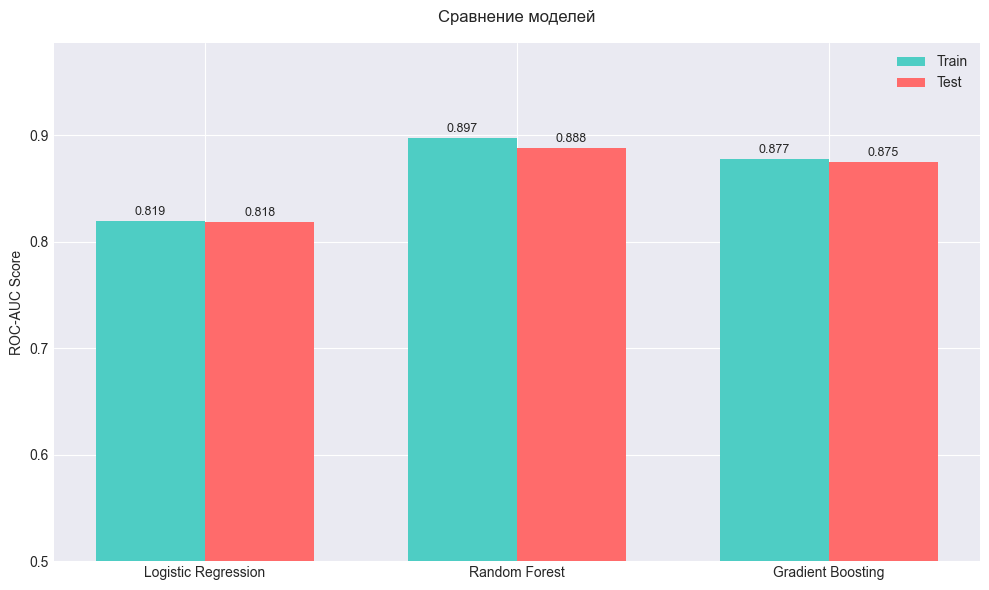

Лучшая модель: Random Forest
ROC-AUC на тесте: 0.8883


In [29]:
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
train_scores = [roc_auc_score(y_train, lr_train_pred), 
                roc_auc_score(y_train, rf_train_pred),
                roc_auc_score(y_train, gb_train_pred)]
test_scores = [roc_auc_score(y_test, lr_test_pred),
               roc_auc_score(y_test, rf_test_pred),
               roc_auc_score(y_test, gb_test_pred)]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, train_scores, width, label='Train', color='#4ecdc4')
bars2 = ax.bar(x + width/2, test_scores, width, label='Test', color='#ff6b6b')

ax.set_ylabel('ROC-AUC Score')
ax.set_title('Сравнение моделей', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

y_max = max(max(train_scores), max(test_scores))
ax.set_ylim([0.5, y_max * 1.1])

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.003, 
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.003, 
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Выбираем лучшую модель
if test_scores[2] > test_scores[1]:
    best_model = gb_model
    best_name = 'Gradient Boosting'
else:
    best_model = rf_model
    best_name = 'Random Forest'

print(f"Лучшая модель: {best_name}")
print(f"ROC-AUC на тесте: {max(test_scores):.4f}")

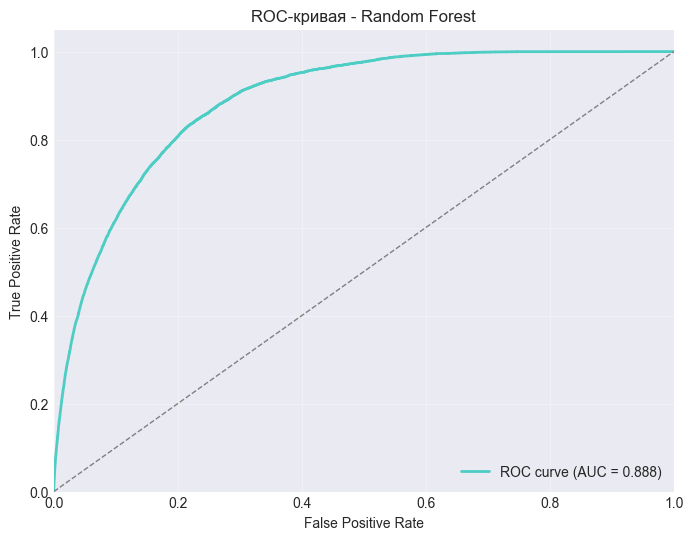

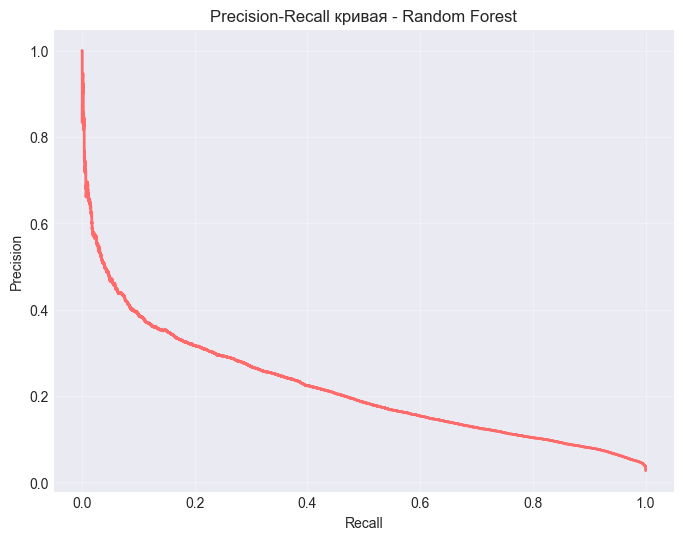

In [30]:
# ROC-кривая
best_pred = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, best_pred)
roc_auc = roc_auc_score(y_test, best_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#4ecdc4', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривая - {best_name}')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Precision-Recall кривая
precision, recall, _ = precision_recall_curve(y_test, best_pred)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#ff6b6b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall кривая - {best_name}')
plt.grid(True, alpha=0.3)
plt.show()

Среди трех обученных моделей наилучший результат показал Случайный лес с ROC-AUC = 0.8883 на тестовой выборке, что свидетельствует о хорошей способности модели различать сессии с конверсией и без нее. Градиентный бустинг показал сопоставимый результат (0.8747), тогда как логистическая регрессия ожидаемо оказалась слабее (0.8183) из-за нелинейного характера зависимостей между признаками и целевой переменной. Важно отметить, что модель Случайного леса демонстрирует минимальный разрыв между тренировочным и тестовым качеством, что говорит об отсутствии переобучения и хорошей обобщающей способности.

Значение ROC-AUC ≈ 0.89 означает, что модель с вероятностью 89% может отличить случайно выбранную конверсионную сессию от случайно выбранной неконверсионной. Полученная Precision-Recall кривая позволяет подобрать оптимальный порог классификации в зависимости от бизнес-целей: если важнее не пропустить потенциального клиента (высокий recall), порог следует снизить; если критично не тратить ресурсы на ложные срабатывания (высокая precision) — порог повысить. Таким образом, модель Случайного леса может быть рекомендована для внедрения в систему прогнозирования конверсии с возможностью настройки порога принятия решений под конкретные бизнес-задачи.

 Анализ важности признаков

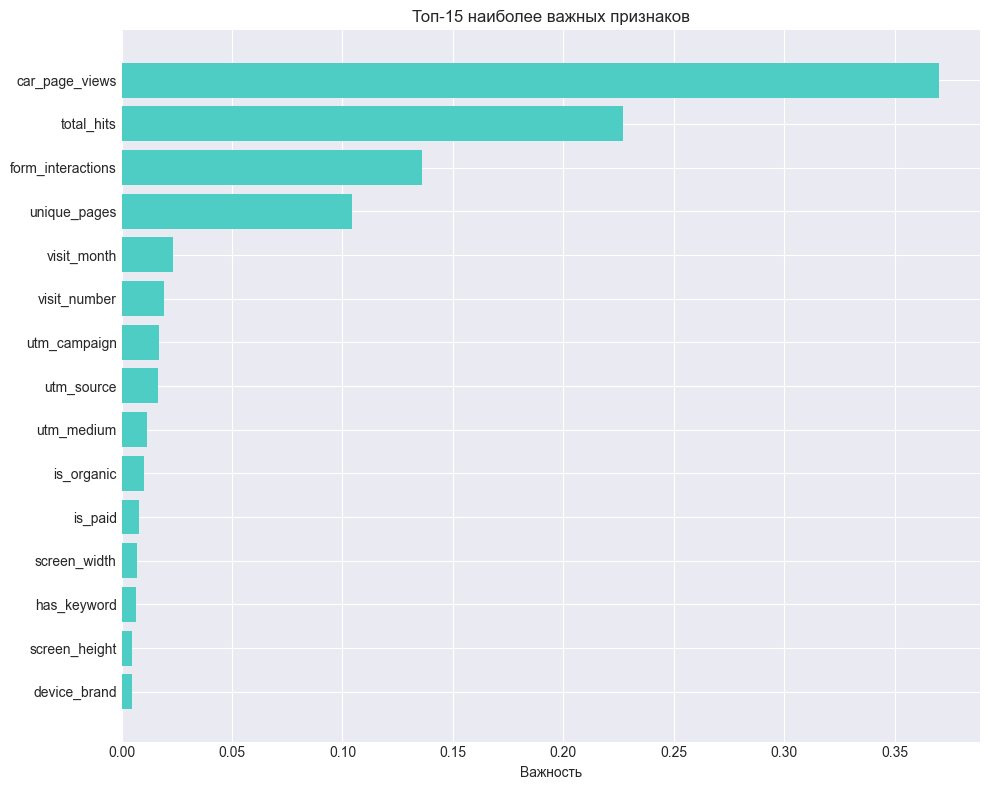

In [31]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = existing_features
    
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    top_features = feature_importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'], color='#4ecdc4')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Важность')
    plt.title('Топ-15 наиболее важных признаков')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [32]:
print("Топ-10 важных признаков:")
for idx, row in feature_importance_df.head(10).iterrows():
    print(f"{row['feature']:25s}: {row['importance']:.4f}")

Топ-10 важных признаков:
car_page_views           : 0.3702
total_hits               : 0.2270
form_interactions        : 0.1359
unique_pages             : 0.1045
visit_month              : 0.0231
visit_number             : 0.0193
utm_campaign             : 0.0168
utm_source               : 0.0163
utm_medium               : 0.0114
is_organic               : 0.0103


Анализ важности признаков для лучшей модели подтверждает и количественно обосновывает выводы, сделанные на этапе EDA. Три ключевых поведенческих признака — car_page_views (37.0%), total_hits (22.7%) и form_interactions (13.6%) — в сумме обеспечивают наибольшую предсказательную силу модели. Это означает, что решение о конверсии практически полностью определяется активностью пользователя на сайте: чем больше страниц с автомобилями он просмотрел, чем больше совершил любых действий и чем активнее взаимодействовал с формами, тем выше вероятность целевого действия. Остальные признаки имеют незначительный вклад. Показательно, что visit_month (2.3%) и visit_number (1.9%) оказались чуть более важными, чем каналы трафика.

## 4. Подготовка артефактов

Сериализация модели: обученная модель и шаги предобработки (пайплайн) будут сохранены с использованием библиотеки joblib.

In [35]:
import os

# Создаем папку для моделей
os.makedirs('model', exist_ok=True)
# Сериализуем и сохраняем полный пайплайн (препроцессинг + алгоритм)
joblib.dump(rf_model, 'model/best_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(existing_features, 'model/features.pkl')

print("Сохранено: best_model.pkl, scaler.pkl, features.pkl")

Сохранено: best_model.pkl, scaler.pkl, features.pkl
